# question 1

Empty DataFrame
Columns: [Unnamed: 0, rating, review]
Index: []


<Axes: xlabel='rating'>

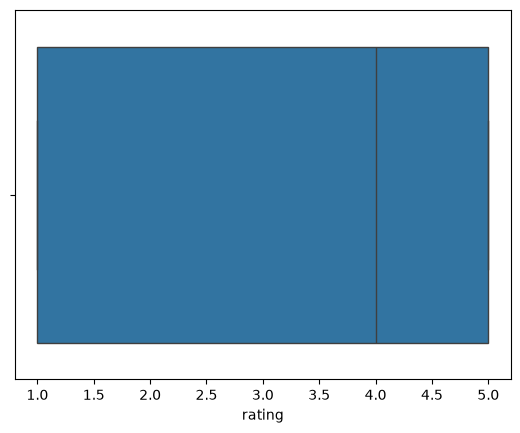

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("zomato_reviews.csv")
q1 = df["rating"].quantile(0.25)
q3 = df["rating"].quantile(0.75)
iqr = q3 - q1
print(df[((df["rating"]<(q1-1.5*iqr)) | (df["rating"]>(q3+1.5*iqr)))])
sns.boxplot(x=df["rating"])

# question 2

<Axes: ylabel='approx_cost(for two people)'>

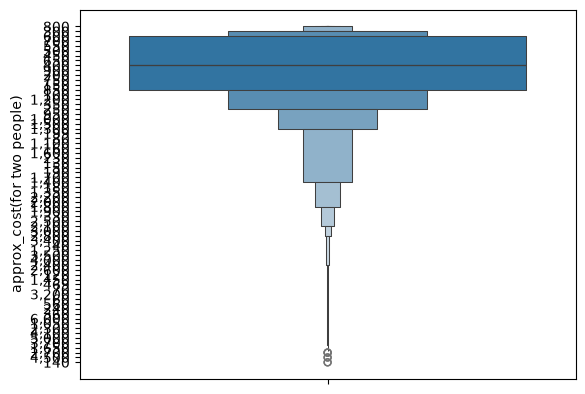

In [4]:
df = pd.read_csv("zomato.csv")
a = df["approx_cost(for two people)"]
sns.boxenplot(a)

# question 3

In [6]:
data = {
    "transaction_amount": [
        100,
        150,
        200,
        250,
        300,
        350,
        400,
        450,
        500,
        5000,
    ]  
}
df = pd.DataFrame(data)

p5 = df["transaction_amount"].quantile(0.05)
p95 = df["transaction_amount"].quantile(0.95)

df["transaction_amount"] = df["transaction_amount"].clip(lower=p5, upper=p95)

print(df["transaction_amount"].describe())
df["transaction_amount"]

count      10.000000
mean      569.750000
std       854.366603
min       122.500000
25%       212.500000
50%       325.000000
75%       437.500000
max      2975.000000
Name: transaction_amount, dtype: float64


0     122.5
1     150.0
2     200.0
3     250.0
4     300.0
5     350.0
6     400.0
7     450.0
8     500.0
9    2975.0
Name: transaction_amount, dtype: float64

# question 4

In [7]:
data = {"price": ["₹1,299", "₹499", "₹12,499", "₹2,000"]}
df = pd.DataFrame(data)

df["price"] = (
    df["price"].str.replace("₹", "", regex=False).str.replace(",", "", regex=False)
)
df["price"] = df["price"].astype(float)  

print(df)
print("\nData Type:")
print(df.dtypes)

     price
0   1299.0
1    499.0
2  12499.0
3   2000.0

Data Type:
price    float64
dtype: object


# question 5

In [8]:
import pandas as pd

# 1. Sample DataFrame with mixed types in 'is_premium'
data = {
    "user_id": [1, 2, 3, 4, 5, 6, 7],
    "is_premium": [True, "True", 1, "yes", "False", 0, "no"],
}
df = pd.DataFrame(data)
def parse_boolean(val):
  if isinstance(val, (bool, int)):
    return bool(val)

  if isinstance(val, str):
    val_lower = val.strip().lower()
    if val_lower in ["true", "1", "yes"]:
      return True

  return False
df["is_premium"] = df["is_premium"].apply(parse_boolean).astype(bool)

print(df)
print("\nUpdated Data Types:")
print(df.dtypes)

   user_id  is_premium
0        1        True
1        2        True
2        3        True
3        4        True
4        5       False
5        6       False
6        7       False

Updated Data Types:
user_id       int64
is_premium     bool
dtype: object
